In [1]:
# from datasets import load_dataset
# ds = load_dataset("OscarNav/spa-eng")

In [2]:
import re
import tensorflow as tf
import numpy as np
from datasets import load_dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Load dataset
dataset = load_dataset("OscarNav/spa-eng")
pairs = dataset["train"][:50000]   # limit to first 50k

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)  # remove punctuation
    return text

english_sentences = []
spanish_sentences = []


for i in range(len(pairs["eng"])):
    en = clean_text(pairs["eng"][i])
    es = clean_text(pairs["spa"][i]) 
    es = "[start] " + es + " [end]"
    english_sentences.append(en)
    spanish_sentences.append(es)

In [4]:
VOCAB_SIZE = 15000
MAX_LEN = 20

eng_tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

spa_tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

eng_tokenizer.adapt(english_sentences)
spa_tokenizer.adapt(spanish_sentences)

eng_tensor = eng_tokenizer(np.array(english_sentences))
spa_tensor = spa_tokenizer(np.array(spanish_sentences))


In [5]:
BATCH_SIZE = 64
VAL_SPLIT = 0.1
TF_MAX_TRAIN_BATCHES = 100  # set to None for full epoch; higher gives better translation quality

num_samples = eng_tensor.shape[0]
val_size = int(num_samples * VAL_SPLIT)

train_eng = eng_tensor[:-val_size]
train_spa = spa_tensor[:-val_size]
val_eng = eng_tensor[-val_size:]
val_spa = spa_tensor[-val_size:]

train_dataset = tf.data.Dataset.from_tensor_slices((train_eng, train_spa))
train_dataset = train_dataset.shuffle(train_eng.shape[0]).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_eng, val_spa)).batch(BATCH_SIZE)

# keep this alias for backward compatibility with existing cells
dataset = train_dataset

print(f"Train samples: {train_eng.shape[0]}")
print(f"Validation samples: {val_eng.shape[0]}")
print(f"TF max train batches per epoch: {TF_MAX_TRAIN_BATCHES}")

Train samples: 45000
Validation samples: 5000
TF max train batches per epoch: 100


**Task 2: The Multi-Head Cross-Attention Layer**

The formula for Cross-attention is very similar to self-attention, except the query(Q) comes from the deoder's output and the key(K), value(V) comes from the encoder output.
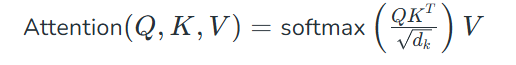 Where, dk is the dimentionality of the keys.

In [6]:
class MultiHeadCrossAttention(tf.keras.layers.Layer):
    def __init__(self, d_model=256, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.Wq = tf.keras.layers.Dense(d_model)
        self.Wk = tf.keras.layers.Dense(d_model)
        self.Wv = tf.keras.layers.Dense(d_model)

        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0,2,1,3])

    def call(self, decoder_input, encoder_output):
        batch_size = tf.shape(decoder_input)[0]

        Q = self.Wq(decoder_input)
        K = self.Wk(encoder_output)
        V = self.Wv(encoder_output)

        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        matmul_qk = tf.matmul(Q, K, transpose_b=True)
        dk = tf.cast(self.depth, tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, V)

        output = tf.transpose(output, perm=[0,2,1,3])
        output = tf.reshape(output, (batch_size, -1, self.d_model))

        return self.dense(output)

**Task 3: Encoder-Decoder Architecture Build a simplified Transformer-style model**

In [7]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model=256):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.self_attn = tf.keras.layers.MultiHeadAttention(
            num_heads=4, key_dim=64)
        self.norm = tf.keras.layers.LayerNormalization()

    def call(self, x):
        x = self.embedding(x)
        attn_output = self.self_attn(x, x)
        return self.norm(x + attn_output)

In [8]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model=256):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.self_attn = tf.keras.layers.MultiHeadAttention(
            num_heads=4, key_dim=64)
        self.cross_attn = MultiHeadCrossAttention(d_model, 4)
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.dense = tf.keras.layers.Dense(vocab_size)

    def call(self, x, encoder_output):
        x = self.embedding(x)
        self_attention = self.self_attn(x, x, use_causal_mask=True)
        x = self.norm1(x + self_attention)

        cross_attention = self.cross_attn(x, encoder_output)
        x = self.norm2(x + cross_attention)

        return self.dense(x)

In [9]:
class Transformer(tf.keras.Model):
    def __init__(self, eng_vocab, spa_vocab):
        super().__init__()
        self.encoder = Encoder(eng_vocab)
        self.decoder = Decoder(spa_vocab)

    def call(self, inputs):
        eng, spa = inputs
        enc_output = self.encoder(eng)
        return self.decoder(spa, enc_output)

In [10]:
model = Transformer(VOCAB_SIZE, VOCAB_SIZE)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True)

optimizer = tf.keras.optimizers.Adam()

**Task 4: Training & Greedy Inference**

In [11]:
# Task 4: Training loop (exactly 20 epochs)
def train_model(model, train_dataset, val_dataset, optimizer, loss_fn, epochs=20, max_batches=None):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        steps = 0

        for batch_idx, (eng, spa) in enumerate(train_dataset):
            decoder_input = spa[:, :-1]
            decoder_target = spa[:, 1:]

            with tf.GradientTape() as tape:
                logits = model((eng, decoder_input), training=True)
                loss = loss_fn(decoder_target, logits)

            gradients = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))

            epoch_loss += float(loss.numpy())
            steps += 1

            if max_batches is not None and (batch_idx + 1) >= max_batches:
                break

        mean_train_loss = epoch_loss / max(steps, 1)
        train_losses.append(mean_train_loss)

        val_epoch_loss = 0.0
        val_steps = 0
        for eng, spa in val_dataset:
            decoder_input = spa[:, :-1]
            decoder_target = spa[:, 1:]
            val_logits = model((eng, decoder_input), training=False)
            val_loss = loss_fn(decoder_target, val_logits)
            val_epoch_loss += float(val_loss.numpy())
            val_steps += 1

        mean_val_loss = val_epoch_loss / max(val_steps, 1)
        val_losses.append(mean_val_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} - "
            f"Train Loss: {mean_train_loss:.4f} - Val Loss: {mean_val_loss:.4f}"
        )

    return train_losses, val_losses


train_losses, val_losses = train_model(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=20,
    max_batches=TF_MAX_TRAIN_BATCHES,
)

Epoch 1/20 - Train Loss: 2.8568 - Val Loss: 1.9694
Epoch 2/20 - Train Loss: 1.7429 - Val Loss: 1.6007
Epoch 3/20 - Train Loss: 1.4293 - Val Loss: 1.4019
Epoch 4/20 - Train Loss: 1.2309 - Val Loss: 1.2823
Epoch 5/20 - Train Loss: 1.0968 - Val Loss: 1.1891
Epoch 6/20 - Train Loss: 1.0010 - Val Loss: 1.1349
Epoch 7/20 - Train Loss: 0.9129 - Val Loss: 1.0827
Epoch 8/20 - Train Loss: 0.8414 - Val Loss: 1.0450
Epoch 9/20 - Train Loss: 0.7707 - Val Loss: 1.0211
Epoch 10/20 - Train Loss: 0.7082 - Val Loss: 0.9987
Epoch 11/20 - Train Loss: 0.6759 - Val Loss: 0.9843
Epoch 12/20 - Train Loss: 0.6405 - Val Loss: 0.9835
Epoch 13/20 - Train Loss: 0.5972 - Val Loss: 0.9614
Epoch 14/20 - Train Loss: 0.5601 - Val Loss: 0.9525
Epoch 15/20 - Train Loss: 0.5308 - Val Loss: 0.9530
Epoch 16/20 - Train Loss: 0.5049 - Val Loss: 0.9412
Epoch 17/20 - Train Loss: 0.4917 - Val Loss: 0.9424
Epoch 18/20 - Train Loss: 0.4505 - Val Loss: 0.9393
Epoch 19/20 - Train Loss: 0.4426 - Val Loss: 0.9350
Epoch 20/20 - Train L

In [18]:
# Display 5 translation samples
for i in range(5):
    print(f"{i+1}. EN: {pairs['eng'][i]}")
    print(f"   ES: {pairs['spa'][i]}\n")

1. EN: When the curtain went up, the stage was dark.
   ES: Al levantarse el telón, la escena estaba oscura.

2. EN: What was Tom doing the last time you saw him?
   ES: ¿Qué estaba haciendo Tom la última vez que lo viste?

3. EN: Why don't you meet me at 2:30?
   ES: ¿Por qué no te encuentras conmigo a las dos y media?

4. EN: I'll talk to Tom later.
   ES: Hablaré con Tom más tarde.

5. EN: Tom was the one who cooked dinner.
   ES: Tom fue el que cocinó la cena.



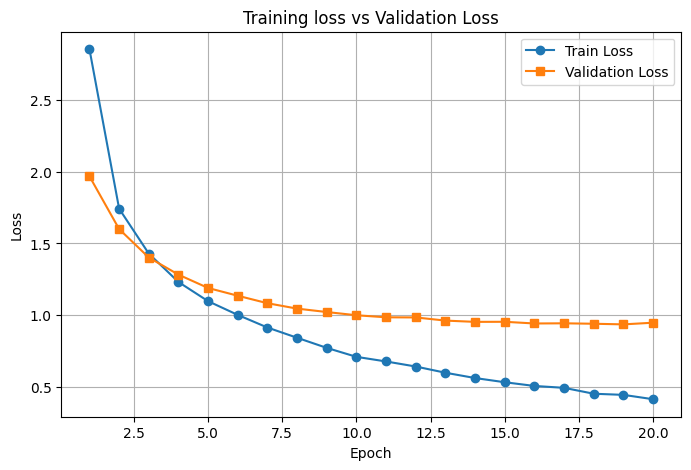

In [19]:
# Plot training loss vs validation loss
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="s", label="Validation Loss")
plt.title("Training loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

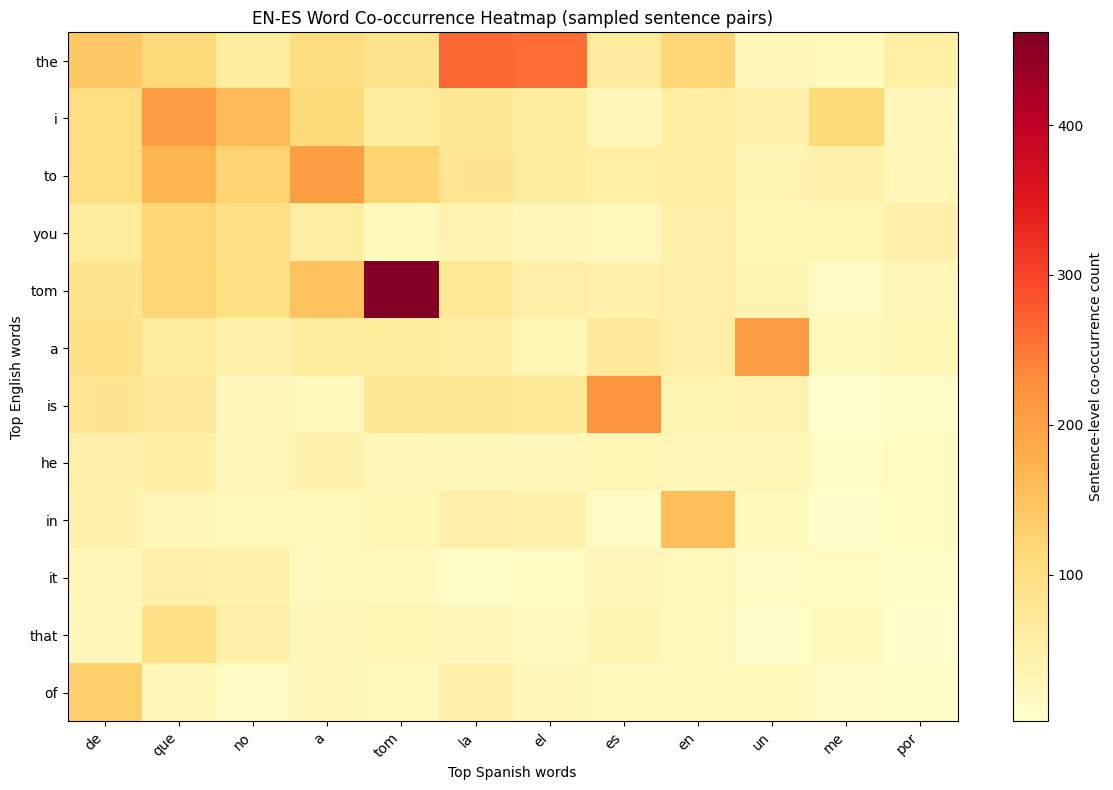

In [22]:
# Heatmap: English-to-Spanish word co-occurrence
from collections import Counter

Dataset = pairs  # use raw parallel text pairs, not tf.data.Dataset
sample_size = min(3000, len(Dataset["eng"]))
top_n = 12

eng_counter = Counter()
spa_counter = Counter()

for i in range(sample_size):
    en_words = clean_text(Dataset["eng"][i]).split()
    es_words = clean_text(Dataset["spa"][i]).split()
    eng_counter.update(en_words)
    spa_counter.update(es_words)

top_eng = [w for w, _ in eng_counter.most_common(top_n)]
top_spa = [w for w, _ in spa_counter.most_common(top_n)]

cooc = np.zeros((top_n, top_n), dtype=np.int32)

for i in range(sample_size):
    en_set = set(clean_text(Dataset["eng"][i]).split())
    es_set = set(clean_text(Dataset["spa"][i]).split())
    for r, en_word in enumerate(top_eng):
        if en_word in en_set:
            for c, es_word in enumerate(top_spa):
                if es_word in es_set:
                    cooc[r, c] += 1

plt.figure(figsize=(12, 8))
plt.imshow(cooc, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="Sentence-level co-occurrence count")
plt.xticks(range(top_n), top_spa, rotation=45, ha="right")
plt.yticks(range(top_n), top_eng)
plt.xlabel("Top Spanish words")
plt.ylabel("Top English words")
plt.title("EN-ES Word Co-occurrence Heatmap (sampled sentence pairs)")
plt.tight_layout()
plt.show()

In [23]:
# Greedy search decoding for English -> Spanish translation
def greedy_search_translate( model, english_sentence, eng_tokenizer, spa_tokenizer, max_len=60, min_decode_steps=3, repetition_penalty=1.5):
    spa_vocab = spa_tokenizer.get_vocabulary()
    token_to_id = {token: idx for idx, token in enumerate(spa_vocab)}

    start_id = token_to_id.get("[start]", token_to_id.get("start"))
    end_id = token_to_id.get("[end]", token_to_id.get("end"))

    if start_id is None or end_id is None:
        raise ValueError("Start/End tokens not found in Spanish tokenizer vocabulary.")

    clean_en = clean_text(english_sentence)
    encoder_input = eng_tokenizer(tf.constant([clean_en]))

    generated_ids = [start_id]
    for _ in range(max_len - 1):
        decoder_input = tf.constant([generated_ids], dtype=encoder_input.dtype)
        logits = model((encoder_input, decoder_input), training=False)
        next_token_logits = logits[0, -1, :].numpy()

        if len(generated_ids) < min_decode_steps:
            next_token_logits[end_id] = -1e9

        for token_id in set(generated_ids[1:]):
            next_token_logits[token_id] -= repetition_penalty

        next_id = int(np.argmax(next_token_logits))
        generated_ids.append(next_id)
        if next_id == end_id:
            break

    generated_tokens = [spa_vocab[idx] if idx < len(spa_vocab) else "[unk]" for idx in generated_ids]
    cleaned_tokens = [
        token for token in generated_tokens
        if token not in {"[start]", "start", "[end]", "end", "", "[pad]", "[UNK]", "[unk]"}
    ]

    return " ".join(cleaned_tokens), generated_tokens


sample_english = "When the curtain went up, the stage was dark."
predicted_translation, raw_generated_tokens = greedy_search_translate(
    model=model,
    english_sentence=sample_english,
    eng_tokenizer=eng_tokenizer,
    spa_tokenizer=spa_tokenizer,
    max_len=MAX_LEN,
    min_decode_steps=3,
    repetition_penalty=1.5,
 )

print("English:", sample_english)
print("Predicted Spanish (greedy):", predicted_translation)
print("Raw generated tokens:", raw_generated_tokens)

English: When the curtain went up, the stage was dark.
Predicted Spanish (greedy): el levantarse al escenario
Raw generated tokens: [np.str_('start'), np.str_('el'), np.str_('levantarse'), np.str_('al'), np.str_('escenario'), np.str_('end')]


In [25]:
# Predict with trained model 

def predict_model(text_input, max_len=MAX_LEN):
    def _predict_one(sentence):
        prediction, _ = greedy_search_translate(
            model=model,
            english_sentence=sentence,
            eng_tokenizer=eng_tokenizer,
            spa_tokenizer=spa_tokenizer,
            max_len=max_len,
            min_decode_steps=3,
            repetition_penalty=1.5,
        )
        return prediction

    if isinstance(text_input, str):
        return _predict_one(text_input)
    if isinstance(text_input, list):
        return [_predict_one(sentence) for sentence in text_input]
    raise TypeError("text_input must be a string or list of strings")

# Example usage
sample_inputs = [
    "When the curtain went up, the stage was dark.",
    "Tom was the one who cooked dinner.",
    "Where is the train station?",
    "What was Tom doing the last time you saw him?",
    " Why don't you meet me at 2:30?",
]

predictions = predict_model(sample_inputs)
for src, pred in zip(sample_inputs, predictions):
    print("EN:", src)
    print("ES:", pred)
    print()

EN: When the curtain went up, the stage was dark.
ES: el levantarse al escenario

EN: Tom was the one who cooked dinner.
ES: tom fue la cena

EN: Where is the train station?
ES: dónde está el tren en la estación

EN: What was Tom doing the last time you saw him?
ES: tom fue lo que le vi a la última vez que le viste a tom

EN:  Why don't you meet me at 2:30?
ES: por qué no me hables de las dos y media



Breif analysis :- 

In neural machine translation, self‑attention and cross‑attention serve distinct but complementary purposes within the Transformer architecture.

Self‑attention operates within a single sequence and enables the model to build an internal representation of that sequence. Each token can examine and weigh information from all other tokens in the same sentence, allowing the model to capture long‑range dependencies. For instance, self‑attention helps resolve references such as linking a pronoun like it to the appropriate noun earlier in the sentence. However, this mechanism is limited to intra‑sequence reasoning and does not establish any relationship between different languages or separate sequences.

Cross‑attention, in contrast, is the component that connects the encoder and decoder. It enables the decoder to align its current state with the encoder’s representations of the input sentence. At every decoding step, the decoder generates queries that attend to the encoder’s output, allowing it to focus selectively on the most relevant parts of the source sentence while producing the next token. This mechanism is what allows the model to map meaning from one language to another.

Together, these two forms of attention enable effective translation: self‑attention builds a rich contextual understanding within each sequence, while cross‑attention transfers that understanding across sequences to support accurate generation in the target language. Without cross‑attention, the decoder would behave like an unconditional language model and generate fluent text in the target language but with no connection to the input. Effective translation therefore requires both mechanisms—one for modeling linguistic structure and the other for grounding the output in the source sentence.

Reference:- 

1. https://www.geeksforgeeks.org/nlp/cross-attention-mechanism-in-transformers/
2. U-Net Transformer: Self and Cross Attention for Medical Image Segmentation:- https://arxiv.org/abs/2103.06104
